In [1]:
import os
import logging
import time

In [2]:
import numpy as np
import pandas as pd

In [3]:
import tensorflow as tf
import tensorflow_recommenders as tfrs

### Read-in data

In [4]:
def load_data_file_cold(file, stats):
    print('loading file:' + file)
    training_df = pd.read_csv(
        file,
        skiprows=[0],
        names=["viewer",
               "broadcaster",
               "viewer_age",
               "viewer_gender",
               "viewer_longitude",
               "viewer_latitude",
               "viewer_lang",
               "viewer_country",
               "broadcaster_age",
               "broadcaster_gender",
               "broadcaster_longitude",
               "broadcaster_latitude",
               "broadcaster_lang",
               "broadcaster_country",
               "duration", 
               "viewer_network", 
               "broadcaster_network", 
               "viewer_lat_long_cluster",
               "rank"], 
        dtype={
            'viewer': np.unicode,
            'broadcaster': np.unicode,
            'viewer_age': np.single,
            'viewer_gender': np.unicode,
            'viewer_longitude': np.single,
            'viewer_latitude': np.single,
            'viewer_lang': np.unicode,
            'viewer_country': np.unicode,
            'broadcaster_age': np.int,
            'broadcaster_longitude': np.single,
            'broadcaster_latitude': np.single,
            'broadcaster_lang': np.unicode,
            'broadcaster_country': np.unicode,
            'viewer_network': np.unicode,
            'broadcaster_network': np.unicode,
            'viewer_lat_long_cluster': np.unicode,
            'rank': np.int
        })

    values = {
        'viewer': 'unknown',
        'broadcaster': 'unknown',
        'viewer_age': 30,
        'viewer_gender': 'unknown',
        'viewer_longitude': 0,
        'viewer_latitude': 0,
        'viewer_lang': 'unknown',
        'viewer_country': 'unknown',
        'broadcaster_age': 30,
        'broadcaster_longitude': 0,
        'broadcaster_latitude': 0,
        'broadcaster_lang': 'unknown',
        'broadcaster_country': 'unknown',
        'duration': 0,
        'viewer_network': 'unknown',
        'broadcaster_network': 'unknown',
        'viewer_lat_long_cluster': '0',
        'rank': 1
    }
    training_df.fillna(value=values, inplace=True)
    print(training_df.head(10))
    print(training_df.iloc[-10:])
    # stats.send_stats('data-size', len(training_df.index))
    samples = training_df.sample(frac=.001)
    return samples


def load_training_data_cold(file, stats):
    ratings_df = load_data_file_cold(file, stats)
    print('creating data set')
    training_ds = (
        tf.data.Dataset.from_tensor_slices(
            ({
                "viewer": tf.cast(
                    ratings_df['viewer'].values,
                    tf.string),
                "viewer_gender": tf.cast(
                    ratings_df['viewer_gender'].values,
                    tf.string),
                "viewer_lang": tf.cast(
                    ratings_df['viewer_lang'].values,
                    tf.string),
                "viewer_country": tf.cast(
                    ratings_df['viewer_country'].values,
                    tf.string),
                "viewer_age": tf.cast(
                    ratings_df['viewer_age'].values,
                    tf.int32),
                "viewer_longitude": tf.cast(
                    ratings_df['viewer_longitude'].values,
                    tf.float16),
                "viewer_latitude": tf.cast(
                    ratings_df['viewer_latitude'].values,
                    tf.float16),
                "broadcaster": tf.cast(
                    ratings_df['broadcaster'].values,
                    tf.string),
                "viewer_network": tf.cast(
                    ratings_df['viewer_network'].values,
                    tf.string),
                "broadcaster_network": tf.cast(
                    ratings_df['broadcaster_network'].values,
                    tf.string),
                "viewer_lat_long_cluster": tf.cast(
                    ratings_df['viewer_lat_long_cluster'].values,
                    tf.string),
            })))

    return training_ds


def prepare_training_data_cold(train_ds):
    print('prepare_training_data')
    training_ds = train_ds.cache().map(lambda x: {
        "broadcaster": x["broadcaster"],
        "viewer": x["viewer"],
        "viewer_gender": x["viewer_gender"],
        "viewer_lang": x["viewer_lang"],
        "viewer_country": x["viewer_country"],
        "viewer_age": x["viewer_age"],
        "viewer_longitude": x["viewer_longitude"],
        "viewer_latitude": x["viewer_latitude"],
        "viewer_network": x["viewer_network"],
        "broadcaster_network": x["broadcaster_network"],
        "viewer_lat_long_cluster": x["viewer_lat_long_cluster"],
    }, num_parallel_calls=tf.data.AUTOTUNE,
       deterministic=False)

    print('done prepare_training_data')
    return training_ds


def current_milli_time():
    return round(time.time() * 1000)

def get_broadcaster_data_set(train_ds):
    broadcasters = train_ds.cache().map(lambda x: x["broadcaster"], num_parallel_calls=tf.data.AUTOTUNE, deterministic=False)
    broadcasters_ds = tf.data.Dataset.from_tensor_slices(
        np.unique(list(broadcasters.as_numpy_iterator())))
    return broadcasters_ds


def get_list(training_data, key):
    return training_data.batch(1_000_000).map(lambda x: x[key], num_parallel_calls=tf.data.AUTOTUNE, deterministic=False)


def get_unique_list(data):
    return np.unique(np.concatenate(list(data)))


In [5]:
print("training_process")
broadcaster_embedding_dimension = 32
viewer_embedding_dimension = 32

batch_size = 1638
learning_rate = 0.05
epochs = 10
top_k = 199

training_process


In [6]:
training_dataset = load_training_data_cold("csv/2021-10-05.csv", "")
train = prepare_training_data_cold(training_dataset)
broadcasters_data_set = get_broadcaster_data_set(training_dataset)

loading file:csv/2021-10-05.csv
                                            viewer  \
0  37 5e 49 40 70 ff b1 a1 51 e1 f0 d6 77 15 d2 32   
1  dd 83 c6 59 b2 3c e3 3c a1 49 47 1c ef 5f 1d 53   
2  d5 e3 54 3c be 21 ee 42 c5 db 19 60 3e 9e b7 72   
3  dd 83 c6 59 b2 3c e3 3c a1 49 47 1c ef 5f 1d 53   
4  08 c7 b8 62 05 d4 b9 80 5b 96 a2 93 0e 48 88 6b   
5  dd 83 c6 59 b2 3c e3 3c a1 49 47 1c ef 5f 1d 53   
6  37 5e 49 40 70 ff b1 a1 51 e1 f0 d6 77 15 d2 32   
7  dd 83 c6 59 b2 3c e3 3c a1 49 47 1c ef 5f 1d 53   
8  37 5e 49 40 70 ff b1 a1 51 e1 f0 d6 77 15 d2 32   
9  dd 83 c6 59 b2 3c e3 3c a1 49 47 1c ef 5f 1d 53   

                                       broadcaster  viewer_age viewer_gender  \
0  34 9a c3 50 0e cf a4 a8 b7 d0 a4 a1 b9 d1 bd f2        43.0        female   
1  b6 cb 91 77 b1 7f 4e 70 be 4d bb 5e 88 3f c2 dd        50.0          male   
2  7f 8c 21 c9 e4 6f a2 fe 01 fa 97 4f 5b 2a 82 3d        22.0        female   
3  73 83 97 f7 28 69 1c 25 4a ca d4 f6 24 9a a6 32   

creating data set
prepare_training_data
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module 'gast' has no attribute 'Constant'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module 'gast' has no attribute 'Constant'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
done prepare_training_data
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module 'gast' has no attribute 'Constant'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to th

2021-10-24 22:44:58.159388: I tensorflow/core/platform/cpu_feature_guard.cc:142] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2021-10-24 22:44:58.303880: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:176] None of the MLIR Optimization Passes are enabled (registered 2)


### Create Models

In [7]:
print("get lists")

user_genders = get_list(train, "viewer_gender")
user_langs = get_list(train, "viewer_lang")
user_countries = get_list(train, "viewer_country")
user_networks = get_list(train, "viewer_network")

viewer_age = get_list(train, "viewer_age")
viewer_longitude = get_list(train, "viewer_longitude")
viewer_latitude = get_list(train, "viewer_latitude")

broadcaster_ids = get_list(train, "broadcaster")

data_set_size = len(broadcaster_ids)

get lists
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module 'gast' has no attribute 'Constant'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module 'gast' has no attribute 'Constant'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module 'gast' has no attribute 'Constant'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity

In [8]:
print("get_unique_list")
unique_broadcasters = get_unique_list(broadcaster_ids)
unique_user_genders = get_unique_list(user_genders)
unique_user_langs = get_unique_list(user_langs)
unique_user_countries = get_unique_list(user_countries)
unique_user_networks = get_unique_list(user_networks)
print(unique_broadcasters)

get_unique_list
[b'00 08 d3 c8 2a 89 77 db 33 af 76 73 a6 56 8d 8d'
 b'00 0c c1 87 07 b9 e3 8b 18 64 f8 9a e6 bd 9f 7f'
 b'00 24 81 7f 78 d5 29 7a db 23 94 82 3c 32 ac 73' ...
 b'ff e3 bb 50 3e f3 e7 74 01 04 f0 d5 22 b9 b4 80'
 b'ff e9 05 7f 97 9e 05 e2 dc 79 ee 39 99 6e 73 a2'
 b'ff f0 a5 3e 66 80 db 05 20 f1 8d 62 fe 23 6c 53']


In [9]:
class UserModel(tf.keras.Model) :

    def __init__(self, unique_genders, unique_langs, unique_countries, viewer_age, unique_networks, unique_clusters) :
        super().__init__()

        self.gender_embedding = tf.keras.Sequential([
            tf.keras.layers.experimental.preprocessing.StringLookup(
                vocabulary=unique_genders, mask_token=None),
            tf.keras.layers.Embedding(len(unique_genders) + 1, 4),
        ])

        self.lang_embedding = tf.keras.Sequential([
            tf.keras.layers.experimental.preprocessing.StringLookup(
                vocabulary=unique_langs, mask_token=None),
            tf.keras.layers.Embedding(len(unique_langs) + 1, 10),
        ])

        self.country_embedding = tf.keras.Sequential([
            tf.keras.layers.experimental.preprocessing.StringLookup(
                vocabulary=unique_countries, mask_token=None),
            tf.keras.layers.Embedding(len(unique_countries) + 1, 10),
        ])

        self.network_embedding = tf.keras.Sequential([
            tf.keras.layers.experimental.preprocessing.StringLookup(
                vocabulary=unique_networks, mask_token=None),
            tf.keras.layers.Embedding(len(unique_networks) + 1, 4),
        ])

        age_boundaries = np.array([18, 25, 30, 35, 40, 45, 50, 55, 60, 65, float("inf")])
        self.viewer_age_embedding = tf.keras.Sequential([
            tf.keras.layers.experimental.preprocessing.Discretization(age_boundaries.tolist()),
            tf.keras.layers.Embedding(len(age_boundaries), 2)
        ])
        
        self.viewer_lat_long_embedding = tf.keras.Sequential([
            tf.keras.layers.experimental.preprocessing.StringLookup(
                vocabulary=unique_clusters, mask_token=None),
            tf.keras.layers.Embedding(len(unique_clusters) + 1, 2),
        ])


    def call(self, inputs) :
        return tf.concat([
            self.gender_embedding(inputs["viewer_gender"]),
            self.lang_embedding(inputs["viewer_lang"]),
            self.country_embedding(inputs["viewer_country"]),
            self.network_embedding(inputs["viewer_network"]),
            self.viewer_age_embedding(inputs["viewer_age"]),
            self.viewer_lat_long_embedding(inputs["viewer_lat_long_cluster"]),
        ], axis = 1)


In [10]:
user_clusters = get_list(train, "viewer_lat_long_cluster")

Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module 'gast' has no attribute 'Constant'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module 'gast' has no attribute 'Constant'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


In [11]:
unique_user_clusters = get_unique_list(user_clusters)
print(unique_user_clusters)

[b'0' b'1' b'2' b'3' b'4' b'5' b'6' b'7']


In [12]:
user_model = UserModel(unique_user_genders, unique_user_langs, unique_user_countries, viewer_age, unique_user_networks, unique_user_clusters)

In [13]:
class BroadcasterModel(tf.keras.Model):

    def __init__(self, unique_broadcaster_titles, dims):
        super().__init__()

        self.broadcaster_embedding = tf.keras.Sequential([
            tf.keras.layers.experimental.preprocessing.StringLookup(
                vocabulary=unique_broadcaster_titles, mask_token=None),
            tf.keras.layers.Embedding(len(unique_broadcaster_titles) + 1, dims)
        ])

    def call(self, broadcaster):
        return tf.concat([
            self.broadcaster_embedding(broadcaster),
        ], axis=1)

In [14]:
broadcaster_model = BroadcasterModel(
    unique_broadcasters,
    broadcaster_embedding_dimension)

In [15]:
metrics = tfrs.metrics.FactorizedTopK(
    candidates=broadcasters_data_set.batch(128).map(broadcaster_model)
)

task = tfrs.tasks.Retrieval(
    metrics=metrics
)


Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


In [16]:
from typing import Dict, Text

class TwoTowers(tf.keras.Model):

    def __init__(self, broadcaster_model, user_model, task):
        super().__init__()
        self.broadcaster_model: tf.keras.Model = broadcaster_model
        self.embedding_model = user_model
        self.task: tf.keras.layers.Layer = task

    def train_step(self, features: Dict[Text, tf.Tensor]) -> tf.Tensor:

        # Set up a gradient tape to record gradients.
        with tf.GradientTape() as tape:

            # Loss computation.

            user_embeddings = self.embedding_model({
                "viewer_gender": features["viewer_gender"],
                "viewer_lang": features["viewer_lang"],
                "viewer_country": features["viewer_country"],
                "viewer_age": features["viewer_age"],
                "viewer_network": features["viewer_network"],
                "viewer_latitude": features["viewer_latitude"],
                "viewer_longitude": features["viewer_longitude"],
                "viewer_lat_long_cluster": features["viewer_lat_long_cluster"]
            })
            positive_broadcaster_embeddings = self.broadcaster_model(
                features["broadcaster"])
            loss = self.task(user_embeddings, positive_broadcaster_embeddings)

            # Handle regularization losses as well.
            regularization_loss = sum(self.losses)

            total_loss = loss + regularization_loss

        gradients = tape.gradient(total_loss, self.trainable_variables)
        self.optimizer.apply_gradients(
            zip(gradients, self.trainable_variables))

        metrics = {metric.name: metric.result() for metric in self.metrics}
        metrics["loss"] = loss
        metrics["regularization_loss"] = regularization_loss
        metrics["total_loss"] = total_loss

        return metrics

    def test_step(self, features: Dict[Text, tf.Tensor]) -> tf.Tensor:

        # Loss computation.

        user_embeddings = self.embedding_model({
                "viewer_gender": features["viewer_gender"],
                "viewer_lang": features["viewer_lang"],
                "viewer_country": features["viewer_country"],
                "viewer_age": features["viewer_age"],
                "viewer_network": features["viewer_network"],
                "viewer_latitude": features["viewer_latitude"],
                "viewer_longitude": features["viewer_longitude"],
                "viewer_lat_long_cluster": features["viewer_lat_long_cluster"]
        })
        positive_broadcaster_embeddings = self.broadcaster_model(
            features["broadcaster"])
        loss = self.task(user_embeddings, positive_broadcaster_embeddings)

        # Handle regularization losses as well.
        regularization_loss = sum(self.losses)

        total_loss = loss + regularization_loss

        metrics = {metric.name: metric.result() for metric in self.metrics}
        metrics["loss"] = loss
        metrics["regularization_loss"] = regularization_loss
        metrics["total_loss"] = total_loss
        return metrics

In [17]:
model = TwoTowers(broadcaster_model, user_model, task)

In [18]:
model.compile(
    optimizer=tf.keras.optimizers.Adagrad(
        learning_rate=learning_rate))

In [19]:
tf.random.set_seed(42)
shuffled = train.shuffle(100_000, seed=42, reshuffle_each_iteration=False)

train_p80 = shuffled.take(80_000)
test_p20 = shuffled.skip(80_000).take(20_000)

cached_train = train_p80.shuffle(100_000).batch(2048)
cached_test = test_p20.batch(2048).cache()

In [20]:
new_model_history = model.fit(
    cached_train,
    validation_data=cached_test,
    validation_freq=5,
    epochs=10,
    verbose=0)

Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module 'gast' has no attribute 'Constant'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the ver

Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module 'gast' has no attribute 'Constant'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module 'gast' has no attribute 'Constant'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module 'gast' has no attribute 'Constant'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


In [21]:
new_model_history.history

{'factorized_top_k/top_1_categorical_accuracy': [0.0003840983263216913,
  0.0,
  0.0,
  0.0,
  0.0003840983263216913,
  0.00019204916316084564,
  0.0,
  0.00019204916316084564,
  0.0,
  0.0007681966526433825],
 'factorized_top_k/top_5_categorical_accuracy': [0.0005761475185863674,
  0.002688688226044178,
  0.005761474836617708,
  0.011907048523426056,
  0.01670827716588974,
  0.020549260079860687,
  0.02554253861308098,
  0.030151719227433205,
  0.035913195461034775,
  0.0418667197227478],
 'factorized_top_k/top_10_categorical_accuracy': [0.0009602458449080586,
  0.005761474836617708,
  0.01267524529248476,
  0.01958901435136795,
  0.02842327579855919,
  0.038793932646512985,
  0.043979257345199585,
  0.05377376452088356,
  0.06932974606752396,
  0.08469368517398834],
 'factorized_top_k/top_50_categorical_accuracy': [0.009602458216249943,
  0.023045899346470833,
  0.04666794836521149,
  0.08450163155794144,
  0.12367966026067734,
  0.16247358918190002,
  0.19704245030879974,
  0.241789

In [22]:
print("create index")
index = tfrs.layers.factorized_top_k.BruteForce(
    query_model=user_model,
    k=top_k,
)

create index


In [23]:
index.index(
    broadcasters_data_set.batch(10000).map(
        model.broadcaster_model),
    broadcasters_data_set)

In [24]:
# Get recommendations.
_, broadcasters = index(
    {
        "viewer_gender": tf.constant(["female"]),
        "viewer_lang": tf.constant(["en"]),
        "viewer_country": tf.constant(["US"]),
        "viewer_age": tf.constant([32]),
        "viewer_longitude": tf.constant([-74.89611]),
        "viewer_latitude": tf.constant([40.36393]),
        "viewer_network": tf.constant(["skout"]),
        "viewer_lat_long_cluster": tf.constant(["7"]),
    }
)
print(f"Recommendations for user cal: {broadcasters}")

Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Recommendations for user cal: [[b'e7 41 84 a9 3a 55 be 0e 4d 2c ea ef 75 e3 cd a1'
  b'e0 2f a9 72 9e d2 66 c2 6e fe 11 2b 88 2e 09 49'
  b'96 ab a4 17 c2 dd c6 bf f9 b0 bd 9a d6 68 84 30'
  b'ac 61 d0 a7 b4 73 c6 c7 64 bf 52 3e eb df 34 d3'
  b'66 b7 2f e1 71 d8 7e fd 44 35 f7 87 5f 4b 99 58'
  b'8a 7b 6e c7 c8 4b 05 f9 d2 c3 1e 75 0a 73 7c 81'
  b'5b d8 dd e3 4f 71 1c 1b 8c

In [28]:
path = "/Users/lhuang/Git/research/Deep-recommender-sandbox/notebooks/models"
tf.saved_model.save (index , path )

Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module 'gast' has no attribute 'Constant'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module 'gast' has no attribute 'Constant'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module 'gast' has no attribute 'Constant'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on

2021-10-24 22:49:25.935633: W tensorflow/python/util/util.cc:348] Sets are not currently considered sequences, but this may change in the future, so consider avoiding using them.


Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set

Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


...

Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert

FOR DEVS: If you are overwriting _tracking_metadata in your class, this property has been used to save metadata in the SavedModel. The metadta field will be deprecated soon, so please move the metadata to a different file.



FOR DEVS: If you are overwriting _tracking_metadata in your class, this property has been used to save metadata in the SavedModel. The metadta field will be deprecated soon, so please move the metadata to a different file.


INFO:tensorflow:Assets written to: /Users/lhuang/Git/research/Deep-recommender-sandbox/notebooks/models/assets


INFO:tensorflow:Assets written to: /Users/lhuang/Git/research/Deep-recommender-sandbox/notebooks/models/assets


### Load model directly

In [7]:
path = "/Users/lhuang/Git/research/Deep-recommender-sandbox/src/save_models/models/debugs"
index = tf.saved_model.load ( path )

In [8]:
# Pass a user id in, get top predicted movie titles back.
score, broadcasters = index(
    {
        "viewer_gender": tf.constant(["female"]),
        "viewer_lang": tf.constant(["en"]),
        "viewer_country": tf.constant(["US"]),
        "viewer_age": tf.constant([32]),
        "viewer_longitude": tf.constant([-74.89611]),
        "viewer_latitude": tf.constant([40.36393]),
        "viewer_network": tf.constant(["skout"]),
        "viewer_lat_long_cluster": tf.constant(["7"]),
    }
)
print(broadcasters)
print(score)

tf.Tensor(
[[b'0c e4 ac c4 59 e3 ac 0a d1 42 28 32 ff ee cf 39'
  b'95 b6 cf 96 87 7a cb c6 8b 38 46 18 0a fd 0d f9'
  b'ac 43 4d 8f 56 f1 2b 43 89 14 69 04 ac 95 a8 53'
  b'50 53 8b 39 3b 22 99 36 49 d3 2a 70 05 9b 02 0e'
  b'00 0c b7 4f c2 d7 53 c8 44 4c a6 73 87 a8 a3 a2'
  b'c4 6e 42 85 18 b1 88 41 8d 83 d7 96 81 38 a3 94'
  b'f8 54 21 b2 ae 00 40 72 d2 17 71 eb 1e 31 95 0e'
  b'a4 1a e2 ef 9c a9 cf cb ba 44 4e 21 fb 9d 90 10'
  b'a4 29 9a 2c 47 50 e0 fb 84 ab ca 8c 52 ea 58 2d'
  b'33 fc 40 07 90 c6 bf 14 2f 01 76 c6 31 da 41 88'
  b'ee e5 2a 72 de db 84 71 a2 38 90 f2 19 fb df e7'
  b'4e d4 a3 54 b4 15 94 c8 41 16 74 4d 50 bd 29 49'
  b'10 a8 c6 40 79 2d c1 11 10 d1 eb 68 cf 2a aa f8'
  b'0d 8c 63 14 b0 1e 51 a0 a7 1e 32 f6 55 13 b9 ce'
  b'5a a8 00 51 2c 18 0f a3 3b 31 5d a0 a8 07 a8 50'
  b'ab b5 3a ea 44 85 8c 61 0f 7a 6e cd ac fa 69 a9'
  b'4b 13 8f 0f 4b 90 1d 0a 85 b5 d1 e6 b2 3c c5 d5'
  b'2b ca 87 55 4f 2f 97 4a 47 ce 46 c6 07 d0 bd 9e'
  b'93 65 79 ec a3 24 11 3d 1f c2 0

### Precision and Recall

https://github.com/tensorflow/recommenders/blob/main/tensorflow_recommenders/examples/movielens.py

In [9]:
raw = load_data_file_cold("csv/2021-10-05.csv", "")


# In[6]:


samples = raw[['viewer_age', 
               'viewer_country', 
               'viewer_gender', 
               'viewer_lang', 
               'viewer_lat_long_cluster', 
               'viewer_latitude', 
               'viewer_longitude', 
               'viewer_network',
               'broadcaster'
              ]].sample(n=1000)

loading file:csv/2021-10-05.csv
                                            viewer  \
0  37 5e 49 40 70 ff b1 a1 51 e1 f0 d6 77 15 d2 32   
1  dd 83 c6 59 b2 3c e3 3c a1 49 47 1c ef 5f 1d 53   
2  d5 e3 54 3c be 21 ee 42 c5 db 19 60 3e 9e b7 72   
3  dd 83 c6 59 b2 3c e3 3c a1 49 47 1c ef 5f 1d 53   
4  08 c7 b8 62 05 d4 b9 80 5b 96 a2 93 0e 48 88 6b   
5  dd 83 c6 59 b2 3c e3 3c a1 49 47 1c ef 5f 1d 53   
6  37 5e 49 40 70 ff b1 a1 51 e1 f0 d6 77 15 d2 32   
7  dd 83 c6 59 b2 3c e3 3c a1 49 47 1c ef 5f 1d 53   
8  37 5e 49 40 70 ff b1 a1 51 e1 f0 d6 77 15 d2 32   
9  dd 83 c6 59 b2 3c e3 3c a1 49 47 1c ef 5f 1d 53   

                                       broadcaster  viewer_age viewer_gender  \
0  34 9a c3 50 0e cf a4 a8 b7 d0 a4 a1 b9 d1 bd f2        43.0        female   
1  b6 cb 91 77 b1 7f 4e 70 be 4d bb 5e 88 3f c2 dd        50.0          male   
2  7f 8c 21 c9 e4 6f a2 fe 01 fa 97 4f 5b 2a 82 3d        22.0        female   
3  73 83 97 f7 28 69 1c 25 4a ca d4 f6 24 9a a6 32   

In [10]:
samples.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1000 entries, 4221372 to 2515768
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   viewer_age               1000 non-null   float32
 1   viewer_country           1000 non-null   object 
 2   viewer_gender            1000 non-null   object 
 3   viewer_lang              1000 non-null   object 
 4   viewer_lat_long_cluster  1000 non-null   object 
 5   viewer_latitude          1000 non-null   float32
 6   viewer_longitude         1000 non-null   float32
 7   viewer_network           1000 non-null   object 
 8   broadcaster              1000 non-null   object 
dtypes: float32(3), object(6)
memory usage: 66.4+ KB


In [11]:
samples

,viewer_age,viewer_country,viewer_gender,viewer_lang,viewer_lat_long_cluster,viewer_latitude,viewer_longitude,viewer_network,broadcaster
4221372,33.0,US,male,en,0,37.318001,-87.338997,skout,0d 1d 88 9f ff 7a 44 76 ea 2a 31 e1 dd c6 75 a7
652260,29.0,US,male,en,0,33.815899,-96.626099,meetme,5b 02 80 ba a6 22 98 55 0d 02 78 03 c6 47 a0 88
253324,24.0,US,female,en,3,35.000000,-118.400002,pof,bc e9 03 bb 9a 98 06 e7 0f 55 fd da 6c 6e 0f bd
5058478,44.0,US,male,en,0,46.544899,-74.282997,meetme,9d b4 5e 36 30 23 0d 2c ab 43 0e de 5d 57 26 02
3275561,50.0,US,male,en,3,50.200001,-122.900002,pof,56 89 17 bb 83 d7 61 f5 73 ef b9 6a 9a 3d 15 1b
...,...,...,...,...,...,...,...,...,...
2545159,32.0,US,male,en,0,30.700001,-95.400002,pof,7d 6a dd b0 3e 23 c1 59 5c 37 da f2 4b ea c2 47
2732015,47.0,US,male,en,2,52.400002,0.100000,pof,b2 f7 1e b6 94 0a 4b 67 e5 e7 b9 fd cf de c0 80
2547267,30.0,US,female,en,0,30.700001,-95.400002,pof,0d ff d7 6b c6 c3 b6 d8 4e 7c f9 db 6d 18 d6 09
294150,24.0,US,male,en,3,35.093899,-117.380096,meetme,8a f2 ec 42 45 37 14 d1 a0 06 15 42 02 93 00 bd


In [34]:
def pred(test_df, k):
    scores, precision_values, recall_values = [], [], []
    df = pd.DataFrame(test_df, columns=['viewer_age', 
               'viewer_country', 
               'viewer_gender', 
               'viewer_lang', 
               'viewer_lat_long_cluster', 
               'viewer_latitude', 
               'viewer_longitude', 
               'viewer_network',
               'broadcaster'
                ])
    for idx, _ in df.iterrows():
        score, pred = index(
            {
                "viewer_gender": tf.constant([df.at[idx, "viewer_gender"]]),
                "viewer_lang": tf.constant([df.at[idx, "viewer_lang"]]),
                "viewer_country": tf.constant([df.at[idx, "viewer_country"]]),
                "viewer_age": tf.constant([int(df.at[idx, "viewer_age"])]),
                "viewer_longitude": tf.constant([df.at[idx, "viewer_longitude"]]),
                "viewer_latitude": tf.constant([df.at[idx, "viewer_latitude"]]),
                "viewer_network": tf.constant([df.at[idx, "viewer_network"]]),
                "viewer_lat_long_cluster": tf.constant([str(df.at[idx, "viewer_lat_long_cluster"])]),
            }
        )
        score = score.numpy()[0]
        newscore = [float(s) for s in score]
        pred = pred.numpy()[0]
        newpred = [s.decode('utf-8') for s in pred]

        res = np.array([newscore, newpred]).T
        topk_broadcasters = res[:k, 1]
#         topk_broadcasters = res[np.argsort(-res[:, 0])[:k], 1]
        num_broadcasters_in_k = sum(x in topk_broadcasters for x in df['broadcaster'].values)
        precision_values.append(num_broadcasters_in_k / k)
        recall_values.append(num_broadcasters_in_k / len(df))
        
    return {
      "k": k,
      "precision_at_k": np.mean(precision_values),
      "recall_at_k": np.mean(recall_values)
    }

In [35]:
res = pred(samples, k=199)

In [36]:
res

{'k': 199,
 'precision_at_k': 0.05151758793969849,
 'recall_at_k': 0.010252000000000002}

### Weighted average predicted scores

In [37]:
def pred_prob(new_df, k=199):
    print(f"len(new_df): {len(new_df)}")
    predprob = []
    df = pd.DataFrame(new_df, columns=['viewer_age', 
               'viewer_country', 
               'viewer_gender', 
               'viewer_lang', 
               'viewer_lat_long_cluster', 
               'viewer_latitude', 
               'viewer_longitude', 
               'viewer_network',
               'broadcaster'
                ])
    ## score dim is decided when building model
    for idx, _ in df.iterrows():
        score, pred = index(
            {
                "viewer_gender": tf.constant([df.at[idx, "viewer_gender"]]),
                "viewer_lang": tf.constant([df.at[idx, "viewer_lang"]]),
                "viewer_country": tf.constant([df.at[idx, "viewer_country"]]),
                "viewer_age": tf.constant([int(df.at[idx, "viewer_age"])]),
                "viewer_longitude": tf.constant([df.at[idx, "viewer_longitude"]]),
                "viewer_latitude": tf.constant([df.at[idx, "viewer_latitude"]]),
                "viewer_network": tf.constant([df.at[idx, "viewer_network"]]),
                "viewer_lat_long_cluster": tf.constant([str(df.at[idx, "viewer_lat_long_cluster"])]),
            }
        )
        
        score = score.numpy()[0]
        k = min(k, len(score))
        ### using normalization over topk scores to get probabilities and take the expectations as predictions
        normalized = [float(s) for s in score[:k]]
        predprob.append(np.average(np.arange(k)/k, weights=normalized))
    return np.mean(predprob)
#     return np.array(predprob)

In [38]:
res = pred_prob(samples, k=199)

len(new_df): 1000


In [39]:
res

0.474025317301956

### Permutation Importance

In [40]:
def permutation_importance(new_df, k, n_repeats):
    X_permuted = new_df.values
    res = []
    baseline_score = pred_prob(X_permuted, k)
    print(baseline_score)
    
    shuffling_idx = np.arange(X_permuted.shape[0])
    for col_idx in range(X_permuted.shape[1]):
        scores = []
        print(f"col_idx:{col_idx}")
        for n_round in range(n_repeats):
            print(f"n_round:{n_round}")
            np.random.shuffle(shuffling_idx)
            X_permuted[:, col_idx] = X_permuted[shuffling_idx, col_idx]
            scores.append(baseline_score - pred_prob(X_permuted, k))
            print(scores)
        res.append(scores)
    return res

In [41]:
shuffled_scores = permutation_importance(samples, 199, 2)

len(new_df): 1000
0.474025317301956
col_idx:0
n_round:0
len(new_df): 1000
[-0.00015321434763398978]
n_round:1
len(new_df): 1000
[-0.00015321434763398978, -0.00018283524845918997]
col_idx:1
n_round:0
len(new_df): 1000
[0.003257269436475252]
n_round:1
len(new_df): 1000
[0.003257269436475252, 0.004030253765282765]
col_idx:2
n_round:0
len(new_df): 1000
[0.004350782249609775]
n_round:1
len(new_df): 1000
[0.004350782249609775, 0.004137094754331827]
col_idx:3
n_round:0
len(new_df): 1000
[0.00416853106026599]
n_round:1
len(new_df): 1000
[0.00416853106026599, 0.003813298652206809]
col_idx:4
n_round:0
len(new_df): 1000
[0.0038075526128004133]
n_round:1
len(new_df): 1000
[0.0038075526128004133, 0.0036682204724635126]
col_idx:5
n_round:0
len(new_df): 1000
[0.0036682204724635126]
n_round:1
len(new_df): 1000
[0.0036682204724635126, 0.0036682204724635126]
col_idx:6
n_round:0
len(new_df): 1000
[0.0036682204724635126]
n_round:1
len(new_df): 1000
[0.0036682204724635126, 0.0036682204724635126]
col_idx:7


In [42]:
shuffled_scores

[[-0.00015321434763398978, -0.00018283524845918997],
 [0.003257269436475252, 0.004030253765282765],
 [0.004350782249609775, 0.004137094754331827],
 [0.00416853106026599, 0.003813298652206809],
 [0.0038075526128004133, 0.0036682204724635126],
 [0.0036682204724635126, 0.0036682204724635126],
 [0.0036682204724635126, 0.0036682204724635126],
 [0.003705581097285693, 0.0037364594074805746],
 [0.0037364594074805746, 0.0037364594074805746]]

In [43]:
samples.columns

Index(['viewer_age', 'viewer_country', 'viewer_gender', 'viewer_lang',
       'viewer_lat_long_cluster', 'viewer_latitude', 'viewer_longitude',
       'viewer_network', 'broadcaster'],
      dtype='object')

In [2]:
import pandas as pd

In [3]:
results = pd.read_csv("/Users/lhuang/Git/research/Deep-recommender-sandbox/src/jobs/results.csv")

In [9]:
results = results[['viewer_age', 'viewer_country', 'viewer_gender', 'viewer_lang',
       'viewer_lat_long_cluster', 'viewer_latitude', 'viewer_longitude',
       'viewer_network']]

In [10]:
results.describe().T.sort_values("50%", ascending=False)

,count,mean,std,min,25%,50%,75%,max
viewer_network,20.0,0.002503,9.901318e-06,0.002490,0.002494,0.002502,0.002512,0.002519
viewer_lat_long_cluster,20.0,0.002493,7.809168e-06,0.002478,0.002489,0.002493,0.002498,0.002510
viewer_latitude,20.0,0.002488,8.898944e-19,0.002488,0.002488,0.002488,0.002488,0.002488
viewer_longitude,20.0,0.002488,8.898944e-19,0.002488,0.002488,0.002488,0.002488,0.002488
viewer_lang,20.0,0.002340,1.349493e-05,0.002320,0.002326,0.002343,0.002346,0.002365
viewer_gender,20.0,0.001938,9.098631e-06,0.001918,0.001933,0.001938,0.001943,0.001953
viewer_country,20.0,0.001933,1.333822e-05,0.001910,0.001922,0.001936,0.001943,0.001952
viewer_age,20.0,0.000252,5.908535e-06,0.000243,0.000249,0.000252,0.000256,0.000263


<AxesSubplot:>

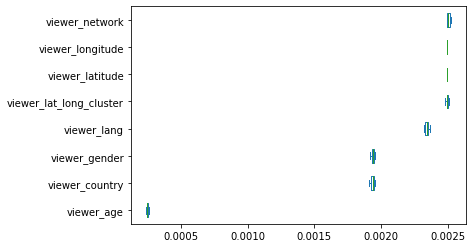

In [12]:
results.plot.box(vert=False)

In [13]:
res = results.describe().T.sort_values("50%", ascending=False)

In [14]:
res.to_csv("res.csv", index=False)

In [16]:
res

,count,mean,std,min,25%,50%,75%,max
viewer_network,20.0,0.002503,9.901318e-06,0.002490,0.002494,0.002502,0.002512,0.002519
viewer_lat_long_cluster,20.0,0.002493,7.809168e-06,0.002478,0.002489,0.002493,0.002498,0.002510
viewer_latitude,20.0,0.002488,8.898944e-19,0.002488,0.002488,0.002488,0.002488,0.002488
viewer_longitude,20.0,0.002488,8.898944e-19,0.002488,0.002488,0.002488,0.002488,0.002488
viewer_lang,20.0,0.002340,1.349493e-05,0.002320,0.002326,0.002343,0.002346,0.002365
viewer_gender,20.0,0.001938,9.098631e-06,0.001918,0.001933,0.001938,0.001943,0.001953
viewer_country,20.0,0.001933,1.333822e-05,0.001910,0.001922,0.001936,0.001943,0.001952
viewer_age,20.0,0.000252,5.908535e-06,0.000243,0.000249,0.000252,0.000256,0.000263
